# Supplementary Figure S5: Scaling Dimensions versus Squeezing

Supplementary Figure S5 shows how decorated-graph scaling dimensions vary with the squeezing parameter $\mu$.

This figure includes:

* scaling dimensions $\Delta_x$, $\Delta_p$, and $\Delta_I/2$ as functions of $\mu$ for a decorated MERA graph

## Import Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox

import loadconfig as loco

import figure_helpers.scaling_dimensions as scaling_dimensions

from graph2grav.figure_hashing import save_figure_with_hash


## Make Figure

Plot decorated scaling dimensions versus squeezing and save the supplementary figure.

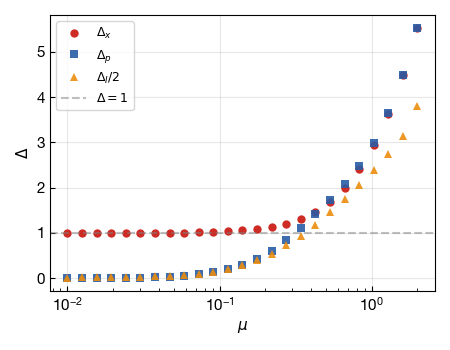

In [2]:
config = loco.reload()

# Figure setup
bbox = Bbox.from_bounds(0.0, 0, 4.5, 3.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

fig, ax = plt.subplots(figsize=(bbox.width, bbox.height))

squeezing_values = np.geomspace(0.01, 2, 25)

scaling_dimensions.plot_scaling_dimensions_vs_squeezing(
    ax,
    squeezing_values=squeezing_values,
    depth=(depth:=6),
    coupling_time=1,
    show_theory_lines=True,
    fraction_to_exclude_x=1/3,
    fraction_to_exclude_p=1/3,
    fraction_to_exclude_mi=1/3,
)

# ax.set_yscale('log')

plt.tight_layout()



if export_figure := True:
    save_figure_with_hash(fig, f'figures/supplementary-figure_decorated-scaling-dimensions-depth-{depth}.pdf')


## Diagnostic: Mutual-Information Scaling

Compare mutual-information scaling across multiple depths. This diagnostic is not part of the paper figure.

figure_helpers.scaling_dimensions.py:55: RuntimeWarning: divide by zero encountered in log
  log_mi = np.log(mi_values[start:end])


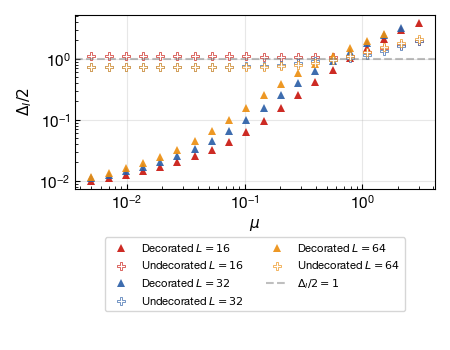

In [ ]:
config = loco.reload()

# Figure setup
bbox = Bbox.from_bounds(0.0, 0, 4.5, 3.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

fig, ax = plt.subplots(figsize=(bbox.width, bbox.height))

squeezing_values = np.geomspace(0.005, 3, 20)

scaling_dimensions.plot_mi_scaling_dimension_multiple_depths(
    ax,
    depths=[4, 5, 6],
    squeezing_values=squeezing_values,
    coupling_time=1.0,
    show_theory_line=True,
    fraction_to_exclude=0,
)

ax.set_yscale('log')

plt.tight_layout()

# This is not one of the figures we export for the paper.
if export_figure := False:
    save_figure_with_hash(fig, 'figures/supplementary-figure_mi-scaling-comparison.pdf')
